# Imports

In [5]:
from langchain_groq import ChatGroq # for LLM
from langchain_huggingface.embeddings import HuggingFaceEmbeddings # for embeddings model
from langchain.tools import tool # for custome tools
from langchain_community.document_loaders.csv_loader import CSVLoader # for loading csv file
from langchain_text_splitters import RecursiveCharacterTextSplitter # for chunking data
from langchain_community.vectorstores import FAISS # for vector db
from langchain_core.messages import SystemMessage, BaseMessage, HumanMessage, AIMessage # for messaging type
from langgraph.graph.message import add_messages # for message adding
from langgraph.prebuilt import ToolNode, tools_condition # for tools conditions
from langchain_core.documents import Document # for document
# youtube search tool
from langchain_community.tools import YouTubeSearchTool
from langchain_community.document_loaders import YoutubeLoader
import ast # convert string into actual python list
# wikipedia search tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
# google search tools
import os
from langchain_community.utilities import SearchApiAPIWrapper
from langchain_core.tools import Tool
# dot env loading
from pathlib import Path
from dotenv import load_dotenv
# for langgraph workflow
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List

In [24]:
env_path = Path("../.env")    # go up one folder
load_dotenv(dotenv_path=env_path)

True

# Model

In [33]:
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Tools

In [34]:
rag_tools = []
web_tools = []

In [35]:
all_docs = []

for csv_path in ["../datasets/data_preprocessed/device_manuals.csv", "../datasets/data_preprocessed//question_answer.csv"]:
    if os.path.exists(csv_path):
        loader = CSVLoader(file_path=csv_path, encoding="latin1")
        docs = loader.load()  # Each row = 1 Document
        all_docs.extend(docs)  # Keep Document objects

In [36]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=800, chunk_overlap=100)
texts = text_splitter.split_documents(all_docs)
texts

[Document(metadata={'source': '../datasets/data_preprocessed/device_manuals.csv', 'row': 0}, page_content=': 0\ncombined_text: Device Name: Insulin Pump. Model Number: DAN246. Manufacturer: Danaher. Indications for Use: Indicated for real-time heart rate assessment in emergency department triage protocols.. Contraindications: Not recommended for use in radiation therapy patients or those with sepsis..'),
 Document(metadata={'source': '../datasets/data_preprocessed/device_manuals.csv', 'row': 1}, page_content=': 1\ncombined_text: Device Name: Ventilator. Model Number: Model 4428. Manufacturer: Fresenius Medical Care. Indications for Use: Intended for infection control evaluation in rehabilitation medicine for chronic conditions recovery.. Contraindications: Not recommended in presence of pulmonary edema or at infected areas locations..'),
 Document(metadata={'source': '../datasets/data_preprocessed/device_manuals.csv', 'row': 2}, page_content=': 2\ncombined_text: Device Name: Surgical R

embed and storing results in FAISS vector db tool

In [37]:
vector_db = FAISS.from_documents(texts, embeddings)

vector search tool

In [38]:
@tool("vector_search")
def vector_search(query: str):
    """Retrieves top 5 results from FAISS for a given query."""
    retriever = vector_db.as_retriever(search_type='similarity', search_kwargs={'k': 5})
    result = retriever.invoke(query)
    context = "\n\n".join([doc.page_content for doc in result])
    print("CONTEXT IN RAG TOOL")
    print(context[:500])
    return context
rag_tools.append(vector_search)

youtube search

In [39]:
@tool("fetch_youtube_content", description="finds youtube videos using YoutubeSearchTool and then fetches content of the link using YoutubeLoader")
def fetch_youtube_content(query: str) -> str:
    """
    Fetches the full transcript text from a YouTube video link.
    """
    youtube_tool = YouTubeSearchTool()

    raw_result = youtube_tool.run(query)
    video_ids = ast.literal_eval(raw_result)
    links = [vid for vid in video_ids]

    all_text = ""
    i = 0
    for link in links:
      all_text += f"Video {i + 1} Content: "
      loader = YoutubeLoader.from_youtube_url(
          link,
          add_video_info=False,
      )
      doc = loader.load()
      all_text += doc[0].page_content + "\n"
      i = i + 1

    return all_text
web_tools.append(fetch_youtube_content)

wikipedia search tool

In [40]:
wikiSearch = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
web_tools.append(wikiSearch)

google web search tool

In [ ]:
# 1) Google Web Search
google_web = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google",            # standard Google web search
)

google_web_tool = Tool(
    name="google_web_search",
    description="General Google web search via SearchApi.io.",
    func=google_web.run,
)

web_tools.append(google_web_tool)

google news search tool

In [ ]:
# 2) Google News
google_news = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google_news",       # Google News vertical
)

google_news_tool = Tool(
    name="google_news_search",
    description="Latest news headlines and articles via Google News (SearchApi.io).",
    func=google_news.run,
)

web_tools.append(google_news_tool)

google scholar search

In [ ]:
# 3) Google Scholar
google_scholar = SearchApiAPIWrapper(
    searchapi_api_key=os.getenv("SEARCHAPI_API_KEY"),
    engine="google_scholar",    # Google Scholar vertical
)

google_scholar_tool = Tool(
    name="google_scholar_search",
    description="Academic papers and scholarly articles via Google Scholar (SearchApi.io).",
    func=google_scholar.run,
)

web_tools.append(google_scholar_tool)

binding LLM with tools

In [ ]:
llm_with_rag_tools = llm.bind_tools(rag_tools)
llm_with_web_tools = llm.bind_tools(web_tools)

In [ ]:
llm_with_rag_tools.invoke("Who is at risk for Lymphocytic Choriomeningitis (LCM)?")

AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

# Lang graph state

In [ ]:
class ChatState(TypedDict):
    question: str # question from the user
    messages: Annotated[List[BaseMessage], add_messages] # all messages history
    phase: str # current phase of the chat web or rag

# Nodes

planning node (Tells the agent what the execution workflow will be)

In [ ]:
def planning(state: ChatState):
    system = SystemMessage(
        content="You are an Agentic RAG assistant. Always try RAG first."
    )
    user = HumanMessage(content=state["question"])

    return {
        "messages": [system, user],
        "phase": "rag"
    }

context search node (this node will bring the context from evaluating rag)

In [ ]:
def context_search(state: ChatState):

    ai_response = llm_with_rag_tools.invoke(state["messages"])

    print("RAG DONE")
    print(state["messages"])
    return {"rag_content": ai_response.content}
        

check relevence node (this node will check if the searched context from rag and web are good enough or they requre more searching)

In [ ]:
def check_relevence(state: ChatState):
    print("STATE")
    print(state)
    context = state['messages'][-1].content

    judge_prompt = f"""
    Question: {state['question']}

    Context:
    {context}

    Is this context sufficient and relevant to answer the question?
    Reply only YES or NO.
    """

    decision = llm.invoke(judge_prompt).content.strip().upper()

    print("---- RELEVANCE CHECK ----")
    print("Context:", context[:300] if context else "No context found")
    print("Decision:", decision)

    if decision == "YES":
        return {"messages": state["messages"]}
    else:
        return {"phase": "web"}

web search node (this node will decide give us web search results)

In [ ]:
def web_search(state: ChatState):

    ai_response = llm_with_web_tools.invoke(state["messages"])

    print("WEB search done")
    return {"web_content": ai_response.content}
    

In [ ]:
def should_continue_web(state: ChatState):
    """Routing function for check_relevence conditional edges"""
    return "web_search" if state["phase"] == "web" else "END"

# Graph

In [ ]:
graph = StateGraph(ChatState)

tools node

In [ ]:
rag_tool_node = ToolNode(rag_tools)
web_tool_node = ToolNode(web_tools)

creating all nodes

In [ ]:
graph.add_node('planning', planning)
graph.add_node('context_search', context_search)
graph.add_node('check_relevence', check_relevence)
graph.add_node('web_search', web_search)
graph.add_node('rag_tools', rag_tool_node)
graph.add_node('web_tools', web_tool_node)

creating add edges

In [ ]:
graph.add_edge(START, "planning")
graph.add_edge('planning', 'context_search')
graph.add_conditional_edges('context_search', tools_condition, {"tools": "rag_tools", "__end__": "check_relevence"})
graph.add_edge('rag_tools', 'context_search')
graph.add_conditional_edges("check_relevence", should_continue_web, {"web_search": "web_search", "END": END})
graph.add_conditional_edges('web_search', tools_condition, {"tools": "web_tools", "__end__": "check_relevence"})
graph.add_edge("web_tools", "web_search")

compiling graph

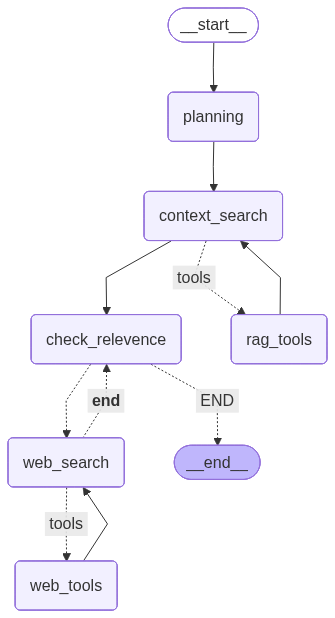

In [ ]:
chatbot = graph.compile()
chatbot

# Question to agent

In [ ]:
initial_state = {
    'question': 'Who is at risk for Lymphocytic Choriomeningitis (LCM)?',
}

res = chatbot.invoke(initial_state)
res

PLANNING DONE
RAG DONE
Relevance DONE
CONTEXT:

decision:  NO


BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: parameters for tool google_web_search did not match schema: errors: [missing properties: '__arg1']", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=google_web_search>{"query": "Lymphocytic Choriomeningitis (LCM) at risk groups"}</function>'}}